In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import os
from pathlib import Path

# Thư mục ĐÃ CÓ SẴN trên Google Drive
WORK_DIR = Path("/content/drive/MyDrive/Lab02_HousePrice ")

# Chỉ chuyển vào thư mục, KHÔNG tạo thư mục mới
os.chdir(WORK_DIR)

print("Đang làm việc tại:", os.getcwd())

Đang làm việc tại: /content/drive/MyDrive/Lab02_HousePrice 


## 1. Import

In [4]:
import os
import json
import warnings
from datetime import datetime, timezone, timedelta
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV, cross_val_score
from sklearn.metrics import mean_squared_error

warnings.filterwarnings("ignore")
np.random.seed(42)
VN_TZ = timezone(timedelta(hours=7))
print("sklearn / pandas OK")

sklearn / pandas OK


## 2. Load dữ liệu

Sửa `DATA_DIR` cho đúng máy bạn:
- Colab + Drive, file nằm trong `Data/`: `Path("Data")`
- Colab, file upload ngay thư mục hiện tại: `Path(".")`
- VS Code, project có folder `data/`: `Path("../data")` hoặc `Path("data")`

In [5]:

DATA = Path("Data")

train_df = pd.read_csv(DATA/"train.csv")
test_df  = pd.read_csv(DATA/ "test.csv")
sample_sub = pd.read_csv(DATA / "sample_submission.csv")

print("Train:", train_df.shape)
print("Test :", test_df.shape)

Train: (1460, 81)
Test : (1459, 80)


## 3. Preprocessing

Fill missing + one-hot, giữ train/test cùng số cột.

In [6]:
y = train_df["SalePrice"].copy()
train_feat = train_df.drop(columns=["SalePrice", "Id"])
test_ids = test_df["Id"].copy()
test_feat = test_df.drop(columns=["Id"])

n_train = len(train_feat)
all_data = pd.concat([train_feat, test_feat], axis=0, ignore_index=True)

num_cols = all_data.select_dtypes(include=[np.number]).columns
cat_cols = all_data.select_dtypes(exclude=[np.number]).columns

all_data[num_cols] = all_data[num_cols].fillna(all_data[num_cols].median())
all_data[cat_cols] = all_data[cat_cols].fillna("None")
all_data = pd.get_dummies(all_data, drop_first=True)

X = all_data.iloc[:n_train].copy()
X_test = all_data.iloc[n_train:].copy()
X_test = X_test.reindex(columns=X.columns, fill_value=0)

print("Số feature sau preprocessing:", X.shape[1])
print("Train X:", X.shape, "| Test X:", X_test.shape)
print("y describe:")
print(y.describe())

Số feature sau preprocessing: 267
Train X: (1460, 267) | Test X: (1459, 267)
y describe:
count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64


## 4. Baseline (Random Forest mặc định)

Để biết tinh chỉnh có cải thiện bao nhiêu.

In [7]:
baseline = RandomForestRegressor(random_state=42, n_jobs=-1)
baseline_scores = cross_val_score(
    baseline, X, y,
    scoring="neg_mean_squared_error",
    cv=5,
    n_jobs=-1,
)
baseline_rmse = float(np.sqrt(-baseline_scores.mean()))
print(f"Baseline Random Forest — CV RMSE: {baseline_rmse:,.2f}")

Baseline Random Forest — CV RMSE: 30,140.04


## 5. Tinh chỉnh siêu tham số (RandomizedSearchCV)

Các nhóm tham số:
- **Số cây**: `n_estimators`
- **Cấu trúc cây**: `max_depth`, `max_features`
- **Điều kiện tách / lá**: `min_samples_split`, `min_samples_leaf`

Muốn kết quả khác: tăng `n_iter` hoặc đổi `random_state`.

In [8]:
param_distributions = {
    "n_estimators": [80, 120, 180, 250],
    "max_depth": [5, 7, 10, 15, None],
    "min_samples_split": [3, 6, 12, 20],
    "min_samples_leaf": [1, 2, 6, 10],
    "max_features": ["sqrt", "log2", 0.3, 0.7],
}

rf_model = RandomForestRegressor(
    random_state=42,
    n_jobs=-1
)

search = RandomizedSearchCV(
    estimator=rf_model,
    param_distributions=param_distributions,
    n_iter=20,
    scoring="neg_mean_squared_error",
    cv=5,
    verbose=1,
    random_state=42,
    n_jobs=-1,
    return_train_score=True,
)

print("Bắt đầu RandomizedSearchCV (Random Forest, 20 cấu hình)...")

search.fit(X, y)

best_cv_rmse = float(np.sqrt(-search.best_score_))

print("\nBest parameters:")
print(search.best_params_)

print(f"Best CV RMSE: {best_cv_rmse:,.2f}")
print(f"Cải thiện so với baseline: {baseline_rmse - best_cv_rmse:,.2f}")

Bắt đầu RandomizedSearchCV (Random Forest, 20 cấu hình)...
Fitting 5 folds for each of 20 candidates, totalling 100 fits

Best parameters:
{'n_estimators': 250, 'min_samples_split': 6, 'min_samples_leaf': 1, 'max_features': 0.3, 'max_depth': None}
Best CV RMSE: 29,107.39
Cải thiện so với baseline: 1,032.66


## 6. Top 10 cấu hình

=== TOP 10 CẤU HÌNH TỐT NHẤT ===
        rmse  param_n_estimators param_max_depth  param_min_samples_split  param_min_samples_leaf param_max_features
29107.387196                 250            None                        6                       1                0.3
29111.675614                 250              15                        3                       1                0.3
29734.785784                 180              10                        3                       1                0.7
29774.365452                  80            None                       12                       2                0.7
29844.683513                 180              15                       12                       2                0.7
30636.979917                  80               7                        3                       2                0.7
30661.638232                 120               7                        6                       2                0.3
30670.335035                 25

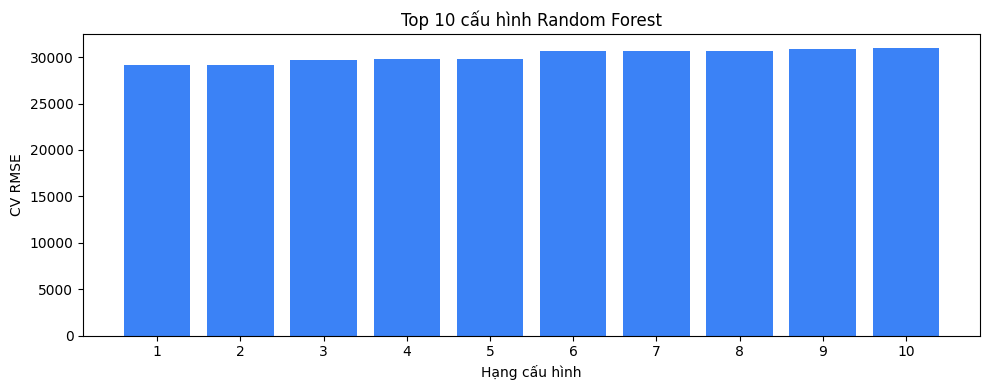

In [9]:
results_df = pd.DataFrame(search.cv_results_)
results_df["rmse"] = np.sqrt(-results_df["mean_test_score"])

top10 = results_df.sort_values("rmse").head(10)[
    [
        "rmse",
        "param_n_estimators",
        "param_max_depth",
        "param_min_samples_split",
        "param_min_samples_leaf",
        "param_max_features",
    ]
].reset_index(drop=True)

print("=== TOP 10 CẤU HÌNH TỐT NHẤT ===")
display(top10) if "display" in dir() else print(top10.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(range(1, len(top10) + 1), top10["rmse"], color="#3b82f6")
ax.set_xlabel("Hạng cấu hình")
ax.set_ylabel("CV RMSE")
ax.set_title("Top 10 cấu hình Random Forest")
ax.set_xticks(range(1, len(top10) + 1))
plt.tight_layout()
plt.show()

## 7. Feature importance

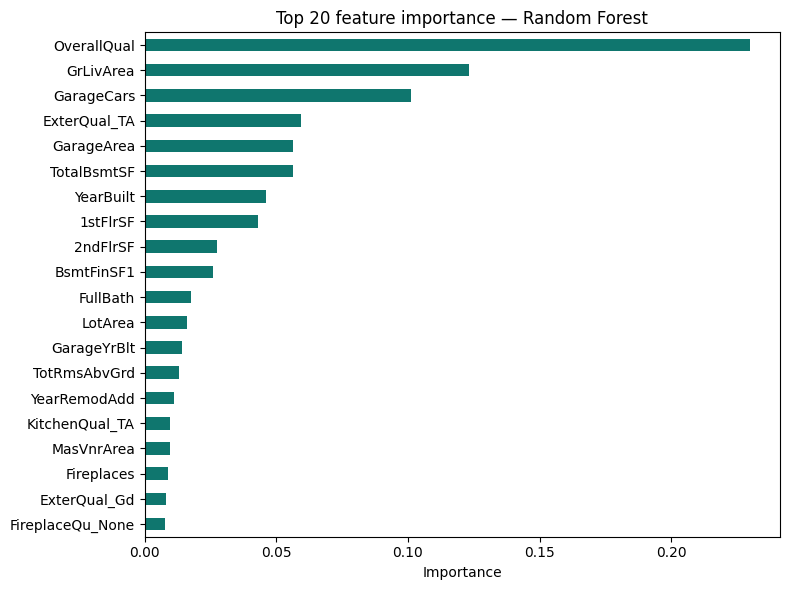

OverallQual         0.229879
GrLivArea           0.123150
GarageCars          0.101317
ExterQual_TA        0.059387
GarageArea          0.056490
TotalBsmtSF         0.056245
YearBuilt           0.045957
1stFlrSF            0.043054
2ndFlrSF            0.027587
BsmtFinSF1          0.026032
FullBath            0.017572
LotArea             0.015849
GarageYrBlt         0.014172
TotRmsAbvGrd        0.013015
YearRemodAdd        0.011040
KitchenQual_TA      0.009698
MasVnrArea          0.009388
Fireplaces          0.008722
ExterQual_Gd        0.008127
FireplaceQu_None    0.007585
dtype: float64


In [10]:
best_model = search.best_estimator_
importances = pd.Series(best_model.feature_importances_, index=X.columns)
top_feat = importances.sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(8, 6))
top_feat.sort_values().plot(kind="barh", ax=ax, color="#0f766e")
ax.set_title("Top 20 feature importance — Random Forest")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()

print(top_feat)

## 8. Predict test set

In [11]:
preds = best_model.predict(X_test)
print("Predictions:", preds.shape, "| min/mean/max:", preds.min(), preds.mean(), preds.max())

Predictions: (1459,) | min/mean/max: 65167.30676568986 179358.1837409878 494020.5791271283


## 9. Lưu experiments/random_forest/<timestamp>/

Mỗi lần chạy cell này tạo **folder mới** theo thời gian (giờ Việt Nam UTC+7), không ghi đè lần cũ.

Vì notebook đã `chdir` vào Google Drive (`MyDrive/Lab02_HousePrice`), file được lưu **trực tiếp trên Drive**:

`Drive/MyDrive/Lab02_HousePrice/experiments/random_forest/<timestamp>/`

Không cần zip / download.

In [12]:
from datetime import datetime, timezone, timedelta

timestamp = datetime.now(timezone(timedelta(hours=7))).strftime("%Y%m%d_%H%M%S")
run_dir = Path("experiments") / "random_forest" / timestamp
run_dir.mkdir(parents=True, exist_ok=True)
print("Đang lưu vào:", run_dir.resolve())
print("Timestamp (giờ VN):", timestamp)

config = {
    "model_name": "random_forest",
    "best_params": search.best_params_,
    "n_iter": 20,
    "cv": 5,
    "scoring": "neg_mean_squared_error",
    "random_state": 42,
    "n_features": int(X.shape[1]),
    "timestamp": timestamp,
}
with open(run_dir / "config.json", "w", encoding="utf-8") as f:
    json.dump(config, f, indent=2, ensure_ascii=False, default=str)

metrics = {
    "best_cv_rmse": best_cv_rmse,
    "baseline_cv_rmse": baseline_rmse,
    "improvement": float(baseline_rmse - best_cv_rmse),
    "n_iter": 20,
    "cv_folds": 5,
}
with open(run_dir / "metrics.json", "w", encoding="utf-8") as f:
    json.dump(metrics, f, indent=2)

joblib.dump(best_model, run_dir / "model.pkl")

sub = sample_sub.copy()
sub["SalePrice"] = preds
sub.to_csv(run_dir / "predictions.csv", index=False)

top10.to_csv(run_dir / "top10_configs.csv", index=False)

sub.to_csv("submission_random_forest.csv", index=False)

print("\nĐã lưu trên Google Drive:")
for f in sorted(run_dir.iterdir()):
    print(" -", f.name, f"({f.stat().st_size} bytes)")
print("\nFile nộp Kaggle: submission_random_forest.csv")

Đang lưu vào: /content/drive/MyDrive/Lab02_HousePrice /experiments/random_forest/20260921_120816
Timestamp (giờ VN): 20260921_120816

Đã lưu trên Google Drive:
 - config.json (329 bytes)
 - metrics.json (151 bytes)
 - model.pkl (11893169 bytes)
 - predictions.csv (34455 bytes)
 - top10_configs.csv (436 bytes)

File nộp Kaggle: submission_random_forest.csv


## 10. So sánh các lần chạy (nếu đã chạy nhiều lần)

In [13]:
exp_dir = Path("experiments") / "random_forest"
print("=== So sánh RMSE các lần chạy Random Forest ===")
if not exp_dir.exists():
    print("Chưa có folder experiments/random_forest")
else:
    rows = []
    for folder in sorted(exp_dir.iterdir()):
        metrics_file = folder / "metrics.json"
        if folder.is_dir() and metrics_file.exists():
            with open(metrics_file, encoding="utf-8") as f:
                m = json.load(f)
            rows.append({
                "folder": folder.name,
                "best_cv_rmse": m.get("best_cv_rmse"),
                "baseline_cv_rmse": m.get("baseline_cv_rmse"),
            })
            print(f"{folder.name}  →  RMSE = {m.get('best_cv_rmse')}")
    if rows:
        cmp_df = pd.DataFrame(rows).sort_values("best_cv_rmse")
        print("\nFolder tốt nhất:", cmp_df.iloc[0]["folder"])

=== So sánh RMSE các lần chạy Random Forest ===
20260921_080702  →  RMSE = 29516.364357849
20260921_082756  →  RMSE = 29072.292685679695
20260921_120816  →  RMSE = 29107.38719564231

Folder tốt nhất: 20260921_082756
